In [2]:
import os
import csv

os.chdir('/Users/rv/Projects/7CS074') # Change to the project root directory

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.base import clone, BaseEstimator, TransformerMixin
from sklearn.model_selection import RandomizedSearchCV, KFold, cross_val_score
from datetime import datetime

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from category_encoders import TargetEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [3]:
BASE_DIR = os.getcwd()

DATA_RAW_PATH = os.path.join(BASE_DIR, "data/raw")
DATA_CLEAN_PATH = os.path.join(BASE_DIR, "data/clean")

DATASET_CLEAN_FILE_PATH = os.path.join(DATA_CLEAN_PATH, "cleaned_dataset.csv")

COLUMNS = [
    "make",
    "model",
    "year",
    "price",
    "transmission",
    "mileage",
    "fuelType",
    "tax",
    "mpg",
    "engineSize",
]

NUMERIC_OUTLIER_COLUMNS = [
    "price",
    "mileage",
    "mpg",
    "engineSize",
    "tax"
]

LOW_CATEGORICAL_FEATURES_OVERALL = [
    'transmission',
    'fuelType'
]

HIGH_CATEGORICAL_FEATURES_GLOBAL = [
    'make',
    'model'
]

HIGH_CATEGORICAL_FEATURES_PER_MAKE = [
    'model'
]

NUMERIC_FEATURES = [
    'year', 
    'tax', 
    'mileage',
    'engineSize',
    'mpg',
    
    # We are making this based on the (mpg/engine size)
    'efficiency_score',
    # We are making this base on (current_year - year)
    'vehicle_age'
]

EXTRA_COLUMNS = ['mileage2', 'fuel type2', 'engine size2', 'reference']
EXPECTED_COLUMNS = 9

In [4]:
def regression_metrics(y_true, y_pred) -> dict:
    """Calculate regression metrics"""
    return {
        "MAPE": np.mean(np.abs((y_true - y_pred) / y_true)) * 100,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

def select_best_model_cv(
    X,
    y,
    models: dict,
    cv_splits: int = 5,
    scoring: str = "neg_mean_absolute_error"
):
    """
        Selects the best model using cross-validation.
    """
    cv = KFold(n_splits=cv_splits, shuffle=True, random_state=42)

    scores = {}
    for name, model in models.items():        
        cv_score = cross_val_score(
            clone(model),
            X,
            y,
            cv=cv,
            scoring=scoring,
            n_jobs=-1
        ).mean()
        scores[name] = cv_score

    best_model_name = max(scores, key=scores.get)
    best_model = clone(models[best_model_name])
    best_model.fit(X, y)

    return best_model_name, best_model, scores

In [5]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """
        Helps with the pipeline to engineer any other features before any training (preprocessed)
        
        - Creates efficiency score to remove the stress on training on two features (mpg and engine size) to determine price, instead just create efficiency score to let model decide on that.
        - Creates vehicle age to better determine the age of vehicle instead of year of manufacture.
    """
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        if {'mpg', 'engineSize'}.issubset(X.columns):

            X['efficiency_score'] = np.where(
                X['engineSize'] > 0,
                X['mpg'] / X['engineSize'],
                np.nan
            )

        if {'year'}.issubset(X.columns):

            current_year = datetime.now().year

            X['vehicle_age'] = current_year - X['year']

        return X

def get_feature_effects(model):
    """
        Returns (values, kind) for feature effect visualization. Since we are using different models, we need to extract feature importance or coefficients based on model type.
        Supported models:
        - Tree models -> feature_importances_ - https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html
        - Linear models -> abs(coef_)
    """
    # Unwrap RandomizedSearchCV -> Pipeline
    if hasattr(model, "best_estimator_"):
        model = model.best_estimator_

    # Unwrap Pipeline -> final estimator step
    if hasattr(model, "named_steps"):
        model = model.named_steps["model"]

    # RandomForest, GradientBoosting, etc.
    if hasattr(model, "feature_importances_"):
        return model.feature_importances_, "importance"

    # LinearRegression, Ridge, Lasso, etc.
    if hasattr(model, "coef_"):
        return np.abs(model.coef_), "coefficient"

    # Unsupported model
    return None, None

In [6]:
def create_preprocessor(
    numeric_features,
    low_card_features,
    high_card_features
):
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                StandardScaler(),
                numeric_features
            ),
            (
                "low_card",
                OneHotEncoder(
                    drop="first",
                    handle_unknown="ignore"
                ),
                low_card_features
            ),
            (
                "high_card",
                TargetEncoder(
                    smoothing=10
                ),
                high_card_features
            )
        ],
        remainder="drop"
    )
    return preprocessor

In [7]:
def create_pipeline(
    numeric_features,
    low_card_features,
    high_card_features,
    model
):
    preprocessor = create_preprocessor(
        numeric_features,
        low_card_features,
        high_card_features
    )

    pipe = Pipeline(
        steps=[
            ("feature_engineering", FeatureEngineer()),
            ("preprocessing", preprocessor),
            ("model", model)
        ]
    )
    return pipe

In [8]:

def get_regression_candidate_models(
    numeric_features,
    low_card_features,
    high_card_features,
    random_state=42,
    cv_splits=5
):
    """
        Returns a list of different regression models, starting with a base model, and hyper tunning others, this can allow to find which is the best model in the case of regression for our current dataset of used cars
    """
    models = {}

    pipe_linear = create_pipeline(
        numeric_features,
        low_card_features,
        high_card_features,
        LinearRegression()
    )

    pipe_rf = create_pipeline(
        numeric_features,
        low_card_features,
        high_card_features,

        RandomForestRegressor(
            n_estimators=300
        )
    )

    rf_param_dist = {
        "model__n_estimators": [100, 300],
        "model__max_depth": [20, 50],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2"]
    }

    rf_random = RandomizedSearchCV(
        estimator=pipe_rf,
        param_distributions=rf_param_dist,
        n_iter=5,
        cv=cv_splits,
        scoring="r2",
        verbose=2,
        n_jobs=1, # I'm not using -1, since my machine cannot process that much data on all CPUs cores
        random_state=random_state
    )

    models["linear"] = pipe_linear
    models["random_forest"] = rf_random

    return models

In [9]:
# First we will check and run the preprocessing script
# In case this is already done, this will not overwrite existing files
def process_raw_multiple_data_files():
    if not os.path.exists(DATA_RAW_PATH):
        raise FileNotFoundError("Data directory not found. Please ensure the project structure is correct.")

    # Creates if not exists
    if not os.path.exists(DATA_CLEAN_PATH):
        os.makedirs(DATA_CLEAN_PATH)

    if os.path.exists(DATASET_CLEAN_FILE_PATH):
        return  # If cleaned dataset already exists, skip processing

    # Creates if not exists, double check at this point
    if not os.path.exists(DATASET_CLEAN_FILE_PATH):
        os.makedirs(DATA_CLEAN_PATH, exist_ok=True)

    directory_raw_bytes = os.fsencode(DATA_RAW_PATH)

    # Validate that CSV files to see if exists and is non-empty
    for file in os.listdir(directory_raw_bytes):
        filename = os.fsdecode(file)
        if filename.endswith(".csv"):
            DATASET_PATH = os.path.join(DATA_RAW_PATH, filename)
            df = pd.read_csv(DATASET_PATH)
            if df.empty:
                raise ValueError("Loaded dataset is empty. Please check the dataset file.")
            continue
        else:
            continue

    # Concatenate all CSV files in the raw data directory
    # We will read the clean path / file directly, and add the default headers
    # We will use our COLUMNS variable as the schema
    schema = COLUMNS
    with open(DATASET_CLEAN_FILE_PATH, 'w') as csvfile:
        writer = csv.writer(csvfile, delimiter=',')
        writer.writerow([g for g in schema])

    for file in os.listdir(directory_raw_bytes):
        filename = os.fsdecode(file)
        if filename.endswith(".csv"):
            DATASET_PATH = os.path.join(DATA_RAW_PATH, filename)
            df_default = pd.read_csv(DATASET_PATH)
            df = clean_data(df_default)

            if not df.empty:
                make = filename.replace('.csv', '')
                df.insert(0, 'make', make) # Insert 'make' as first column
                
                # Only keep rows with exactly EXPECTED_COLUMNS + 1 columns after inserting 'make'
                df = df[df.apply(lambda x: len(x) == EXPECTED_COLUMNS + 1, axis=1)]

                df.to_csv(
                    DATASET_CLEAN_FILE_PATH,
                    mode='a',
                    header=False,
                    index=False
                )
        else:
            continue

def remove_iqr_outliers(
    df: pd.DataFrame,
    columns: list,
    factor: float = 1.5
) -> pd.DataFrame:
    """
        Remove outliers using Interquartile Range (IQR) method for selected columns.
    """
    df = df.copy()

    for col in columns:
        if col not in df.columns:
            continue

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR

        df = df[(df[col] >= lower) & (df[col] <= upper)]

    return df

def apply_domain_constraints(
    df: pd.DataFrame
) -> pd.DataFrame:
    """
        Apply domain constraints to the dataframe, meaning that we filter the data based on known valid ranges for each numeric column, so that we remove any rows that have values outside these ranges.
    """
    df = df.copy()

    constraints = {
        'price': lambda x: (x > 100) & (x < 200_000),
        'mileage': lambda x: (x >= 0) & (x < 300_000),
        'engineSize': lambda x: (x > 0) & (x < 12.0),
        'mpg': lambda x: (x > 5) & (x < 60),
        'tax': lambda x: (x >= 0)
    }

    for col, condition in constraints.items():
        if col in df.columns:
            df = df[condition(df[col])]

    return df

def coerce_numeric_columns(
    df: pd.DataFrame, 
    columns: list
) -> pd.DataFrame:
    """
        Here we make sure that any columns parse we parse to integers / numeric values, if record in column is string of currency numeric, we remove this regex
    """
    df = df.copy()

    for col in columns:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.replace(r"[£,]", "", regex=True)
                .str.strip()
            )
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

# Cleans the data, and returns copy of cleaned dataframe
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """
        Here we clean out the data from any possible problems which can cause bad training
    """
    df = df.copy()
    
    # Remove extra columns and duplicate columns if present
    df.drop(columns=[col for col in EXTRA_COLUMNS if col in df.columns], inplace=True, errors='ignore')
    df = df.loc[:, ~df.columns.duplicated()]
    
    # Only keep rows with exactly EXPECTED_COLUMNS columns
    df = df[df.apply(lambda x: len(x) == EXPECTED_COLUMNS, axis=1)]
    
    # Replace 'N/A' and Drop record duplicates
    # If by any chance 'N/A' is a string by text, we shall change it to nan 'na', later we will remove anyway
    df.replace("N/A", np.nan, inplace=True)
    df.drop_duplicates(inplace=True)

    # Drop rows that are all empty or just commas 
    # """
    #     ,,,,,,,,,,
    # """
    df.replace(r'^\s*$', np.nan, regex=True, inplace=True)
    df.dropna(how='all', inplace=True)

    # Coerce numeric columns
    df = coerce_numeric_columns(df, NUMERIC_OUTLIER_COLUMNS)
    # Domain filtering
    df = apply_domain_constraints(df)
    # Statistical outliers
    df = remove_iqr_outliers(
        df,
        columns=[c for c in NUMERIC_OUTLIER_COLUMNS if c in df.columns]
    )
    
    return df

process_raw_multiple_data_files()

In [10]:
if not os.path.exists(DATASET_CLEAN_FILE_PATH):
    raise FileNotFoundError(f"Dataset not found at {DATASET_CLEAN_FILE_PATH}. Please ensure the dataset is placed correctly.")

df = pd.read_csv(DATASET_CLEAN_FILE_PATH, sep=',', engine='python') # read with proper delimiter handling, and with python engine always
if df.empty:
    raise ValueError("Loaded dataset is empty. Please check the dataset file.")

print(f"Data loaded successfully from {DATASET_CLEAN_FILE_PATH}.")

target_col = 'price'

min_samples_per_make=300
cv_splits=5

trained_models_per_make = {}

Data loaded successfully from /Users/rv/Projects/7CS074/data/clean/cleaned_dataset.csv.


In [11]:
candidate_models = get_regression_candidate_models(
    NUMERIC_FEATURES,
    LOW_CATEGORICAL_FEATURES_OVERALL,
    HIGH_CATEGORICAL_FEATURES_GLOBAL,
    random_state=42,
    cv_splits=cv_splits
)

Y_global = df[target_col]
X_global = df.drop(columns=[target_col])

global_X_train, global_X_test, global_y_train, global_y_test = train_test_split(
    X_global, Y_global, test_size=0.2, random_state=42
)

global_best_name, global_best_model, global_cv_scores = select_best_model_cv(
    global_X_train, global_y_train, candidate_models, cv_splits
)

global_predictions = global_best_model.predict(global_X_test)

pipeline = (
    global_best_model.best_estimator_
    if hasattr(global_best_model, "best_estimator_")
    else global_best_model
)

global_feature_names = pipeline.named_steps[
    "preprocessing"
].get_feature_names_out()

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time=   1.1s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time=   1.2s
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time=   1.1s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time=   1.1s


/Users/rv/Projects/7CS074/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time=   1.1s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time=   1.1s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time=   1.1s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time=   1.2s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time=   1.3s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time=   1.3s
[CV] END model__max_depth=20, model__max_features=sqrt, model__m

/Users/rv/Projects/7CS074/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time=   1.0s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time=   1.0s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time=   1.0s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time=   1.0s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time=   1.0s
[CV] END model__max_depth=50, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=100; total time=   1.1s
[CV] END model__max_depth=50, model__max_features=log2, model__mi

...

[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100; total time=   1.9s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100; total time=   1.9s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100; total time=   1.8s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100; total time=   1.8s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100; total time=   2.1s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100; total time=   2.2s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_sam

/Users/rv/Projects/7CS074/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=20, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=10, model__n_estimators=100; total time=   1.0s
[CV] END model__max_depth=20, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=10, model__n_estimators=100; total time=   1.0s
[CV] END model__max_depth=20, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=10, model__n_estimators=100; total time=   1.1s
[CV] END model__max_depth=20, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=10, model__n_estimators=100; total time=   1.1s
[CV] END model__max_depth=20, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=10, model__n_estimators=100; total time=   1.0s
[CV] END model__max_depth=20, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=10, model__n_estimators=100; total time=   1.0s
[CV] END model__max_depth=20, model__max_features=log2, model__m

/Users/rv/Projects/7CS074/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=20, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=10, model__n_estimators=100; total time=   1.0s
[CV] END model__max_depth=20, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=10, model__n_estimators=100; total time=   1.1s
[CV] END model__max_depth=20, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=10, model__n_estimators=100; total time=   1.1s
[CV] END model__max_depth=20, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=10, model__n_estimators=100; total time=   1.1s
[CV] END model__max_depth=20, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=10, model__n_estimators=100; total time=   1.1s
[CV] END model__max_depth=20, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=10, model__n_estimators=100; total time=   1.1s
[CV] END model__max_depth=20, model__max_features=log2, model__m

In [13]:
# Per-make models
# If the length of each dataframe of group is lower than the minimum sample variable, we shall pass and not create a 'per-make' model
# This is to make sure that algorithms like 'Random Forrest' gets trained on larger sets of data, as indented, if the condition is true, the make would fallback into the global model above.

candidate_models_per_make = get_regression_candidate_models(
    NUMERIC_FEATURES,
    LOW_CATEGORICAL_FEATURES_OVERALL,
    HIGH_CATEGORICAL_FEATURES_PER_MAKE,
    random_state=42,
    cv_splits=cv_splits
)

for make, group_df in df.groupby("make"):
    if len(group_df) < min_samples_per_make:
        continue
    
    Y = group_df[target_col]
    X = group_df.drop(columns=[target_col])

    X_train, X_test, y_train, y_test = train_test_split(
        X, Y, test_size=0.2, random_state=42
    )

    best_name, best_model, cv_scores = select_best_model_cv(
        X_train, y_train, candidate_models_per_make, cv_splits
    )

    predictions = best_model.predict(X_test)
    trained_models_per_make[make] = {
        "best_model_name": best_name,
        "model": best_model,
        "feature_names": X_train.columns,
        "X_test": X_test,
        "y_test": y_test,
        "predictions": predictions,
    }

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time=   0.1s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time=   0.2s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time=   0.2s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time=   0.2s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time=   0.2s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_sample

/Users/rv/Projects/7CS074/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/rv/Projects/7CS074/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time=   0.2s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time=   0.2s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time=   0.2s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time=   0.2s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time=   0.2s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time=   0.2s
[CV] END model__max_depth=20, model__max_features=sqrt, model__m

/Users/rv/Projects/7CS074/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/rv/Projects/7CS074/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=50, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=100; total time=   0.2s
[CV] END model__max_depth=50, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=100; total time=   0.2s
[CV] END model__max_depth=50, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=100; total time=   0.2s
[CV] END model__max_depth=50, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=100; total time=   0.2s
[CV] END model__max_depth=50, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=100; total time=   0.2s
[CV] END model__max_depth=50, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=100; total time=   0.2s
[CV] END model__max_depth=50, model__max_features=log2, model__min_sam

...

[CV] END model__max_depth=20, model__max_features=log2, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100; total time=   0.2s
[CV] END model__max_depth=20, model__max_features=log2, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100; total time=   0.2s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100; total time=   0.2s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100; total time=   0.2s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100; total time=   0.2s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100; total time=   0.2s


/Users/rv/Projects/7CS074/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100; total time=   0.2s
[CV] END model__max_depth=20, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=10, model__n_estimators=100; total time=   0.1s
[CV] END model__max_depth=20, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=10, model__n_estimators=100; total time=   0.1s
[CV] END model__max_depth=20, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=10, model__n_estimators=100; total time=   0.1s


/Users/rv/Projects/7CS074/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=20, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=10, model__n_estimators=100; total time=   0.1s
[CV] END model__max_depth=20, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=10, model__n_estimators=100; total time=   0.1s
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time=   0.3s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time=   0.3s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_l

In [14]:
global_metrics = regression_metrics(y_test, predictions)

In [15]:
print(f"\n Overall Dataset:")
print(f"  Best Model: {global_best_name}")
print(f"  MAE: £{global_metrics['MAE']:.2f}")
print(f"  RMSE: £{global_metrics['RMSE']:.2f}")
print(f"  R²: {global_metrics['R2']:.3f}")
print(f"  MAPE: {global_metrics['MAPE']:.2f}%")

for make_vehicle, data in trained_models_per_make.items():
	y_test = data['y_test']
	predictions = data['predictions']
	metrics = regression_metrics(y_test, predictions)

	print(f"\n{make_vehicle}:")
	print(f"  Best Model: {data['model']}")
	print(f"  MAE: £{metrics['MAE']:.2f}")
	print(f"  RMSE: £{metrics['RMSE']:.2f}")
	print(f"  R²: {metrics['R2']:.3f}")
	print(f"  MAPE: {metrics['MAPE']:.2f}%")


 Overall Dataset:
  Best Model: random_forest
  MAE: £1206.84
  RMSE: £1686.06
  R²: 0.918
  MAPE: 5.89%

audi:
  Best Model: RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('feature_engineering',
                                              FeatureEngineer()),
                                             ('preprocessing',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['year',
                                                                                'tax',
                                                                                'mileage',
                                                                                'engineSize',
                                                                                'mpg',
                    

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

def plot_feature_importances(values, feature_names, title):
    """Horizontal bar plot of feature importances/coefficients"""
    importance_df = (
        pd.DataFrame({
            "feature": feature_names,
            "importance": values
        })
        .sort_values("importance", ascending=False)
        .head(20)
    )

    plt.figure(figsize=(10, 8))
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(importance_df)))
    plt.barh(importance_df["feature"], importance_df["importance"], 
             color=colors, edgecolor='black', linewidth=0.8)
    plt.gca().invert_yaxis()
    plt.xlabel('Importance', fontsize=12)
    plt.title(title, fontsize=16, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

def plot_price_vs_mpg(df: pd.DataFrame):
    """Scatter plot of price vs MPG"""
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='mpg', y='price', alpha=0.5)
    plt.title("Price vs MPG", fontsize=16, fontweight='bold')
    plt.xlabel("MPG", fontsize=12)
    plt.ylabel("Price (£)", fontsize=12)
    plt.tight_layout()
    plt.show()
    
def plot_price_vs_milage(df: pd.DataFrame):
    """Scatter plot of price vs milage"""
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='milage', y='price', alpha=0.5)
    plt.title("Price vs Milage", fontsize=16, fontweight='bold')
    plt.xlabel("Milage", fontsize=12)
    plt.ylabel("Price (£)", fontsize=12)
    plt.tight_layout()
    plt.show()

def plot_actual_vs_predicted(actuals, predictions, model_name, R_SQUARE):
    """Scatter plot of actual vs predicted values for regression"""
    plt.figure(figsize=(10, 8))
    plt.scatter(actuals, predictions, alpha=0.4, c="teal", label="Predicted vs Actual", s=50)
    plt.plot([min(actuals), max(actuals)], [min(actuals), max(actuals)],
             "r--", label="Perfect Prediction (Actual = Predicted)", linewidth=2)
    plt.xlabel("Actual Price (£)", fontsize=12)
    plt.ylabel("Predicted Price (£)", fontsize=12)
    plt.title(f"Actual vs Predicted Price\nR² = {R_SQUARE:.3f} - {model_name}", 
              fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

def plot_residuals(actuals, predictions, model_name):
    """Plot residuals for regression analysis"""
    residuals = actuals - predictions
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Residual plot
    axes[0].scatter(predictions, residuals, alpha=0.4, c='steelblue')
    axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
    axes[0].set_xlabel("Predicted Price (£)", fontsize=12)
    axes[0].set_ylabel("Residuals", fontsize=12)
    axes[0].set_title(f"Residual Plot - {model_name}", fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # Residual histogram
    axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[1].set_xlabel("Residuals", fontsize=12)
    axes[1].set_ylabel("Frequency", fontsize=12)
    axes[1].set_title("Residual Distribution", fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

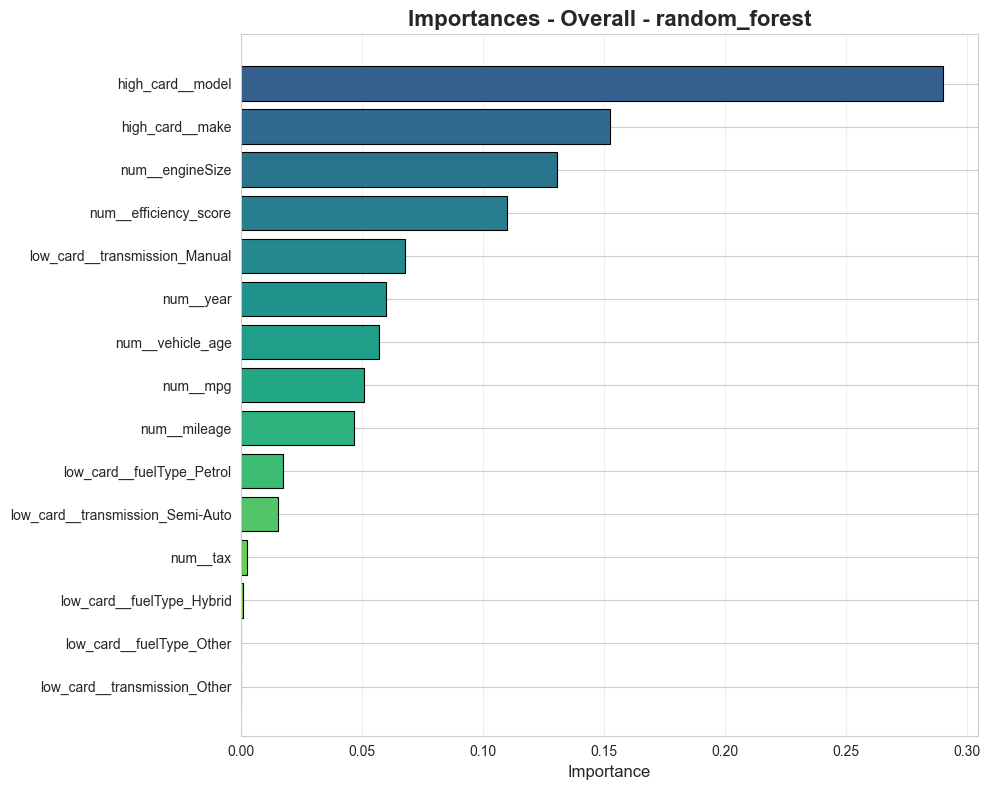

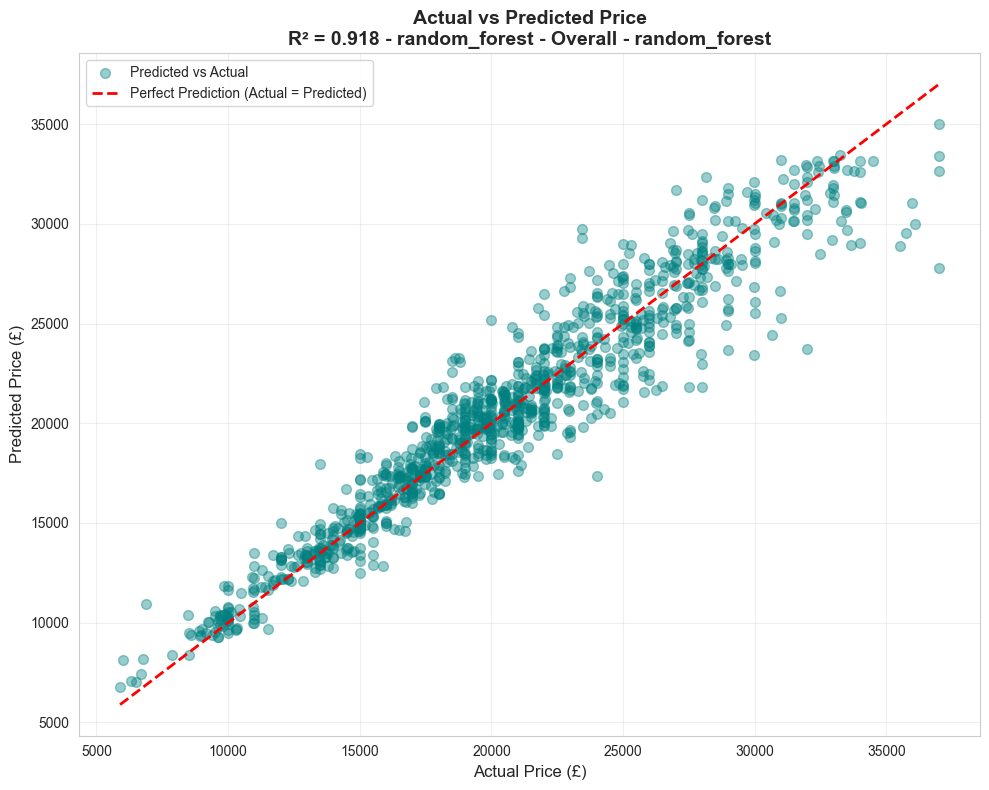

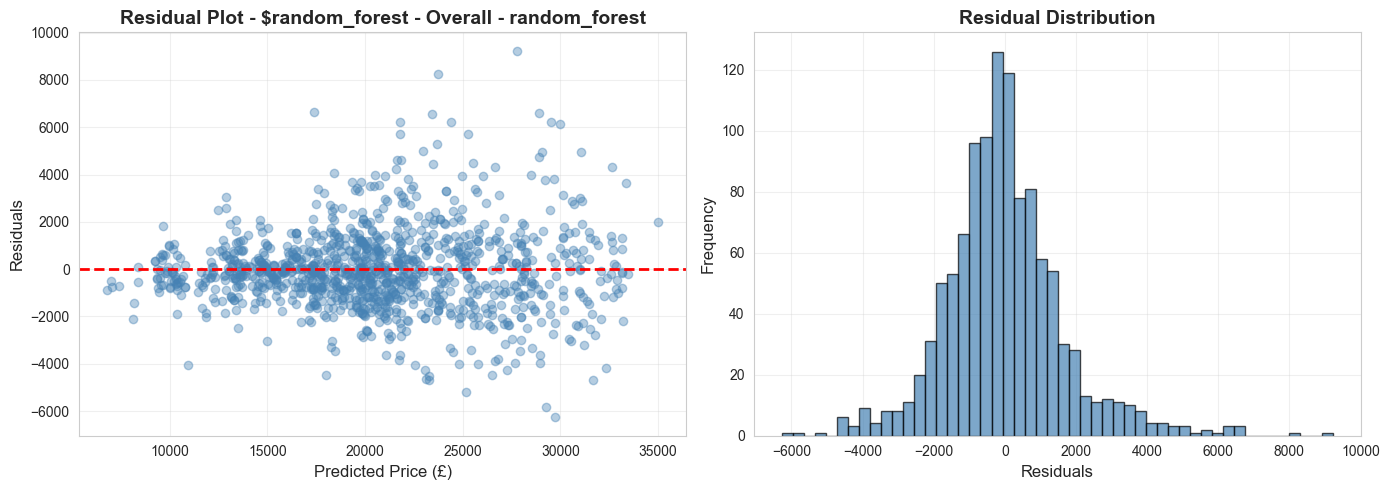

In [18]:
values, kind = get_feature_effects(global_best_model)

plot_feature_importances(
	values,
	global_feature_names,
	f"{kind.title()}s - Overall - {global_best_name}"
)

# Actual vs Predicted
plot_actual_vs_predicted(
	y_test, 
	predictions, 
	f'{global_best_name} - Overall - {global_best_name}', 
	metrics['R2']
)

# Residuals plot
plot_residuals(
	y_test, 
	predictions, 
	f'${global_best_name} - Overall - {global_best_name}'
)

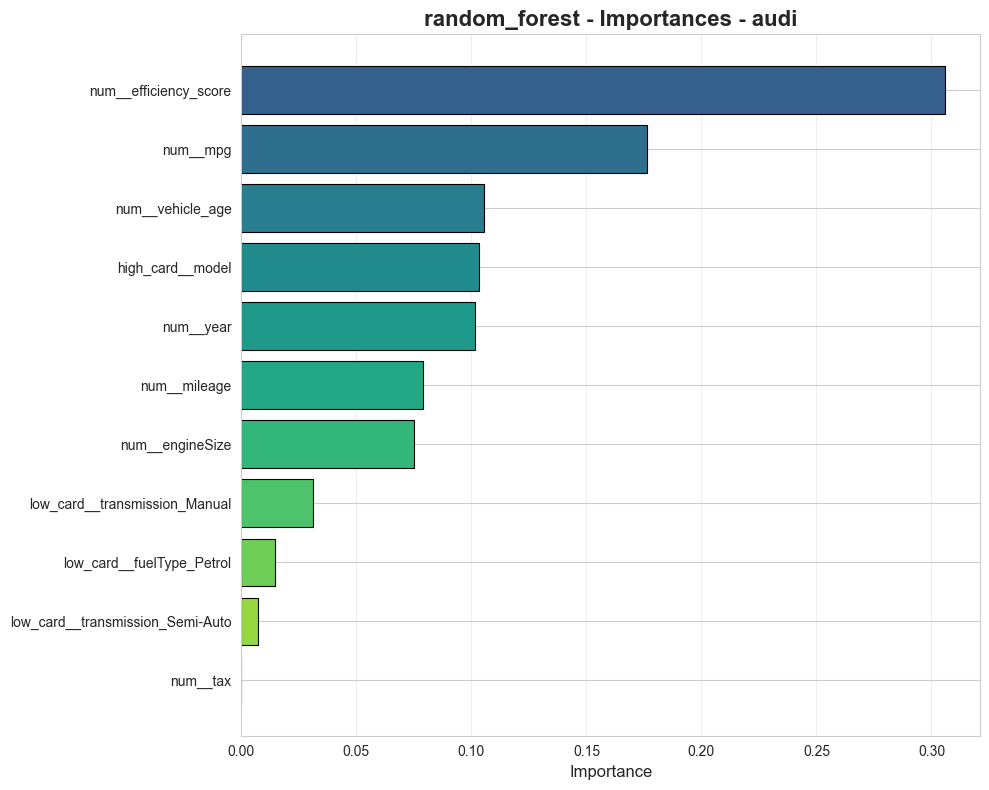

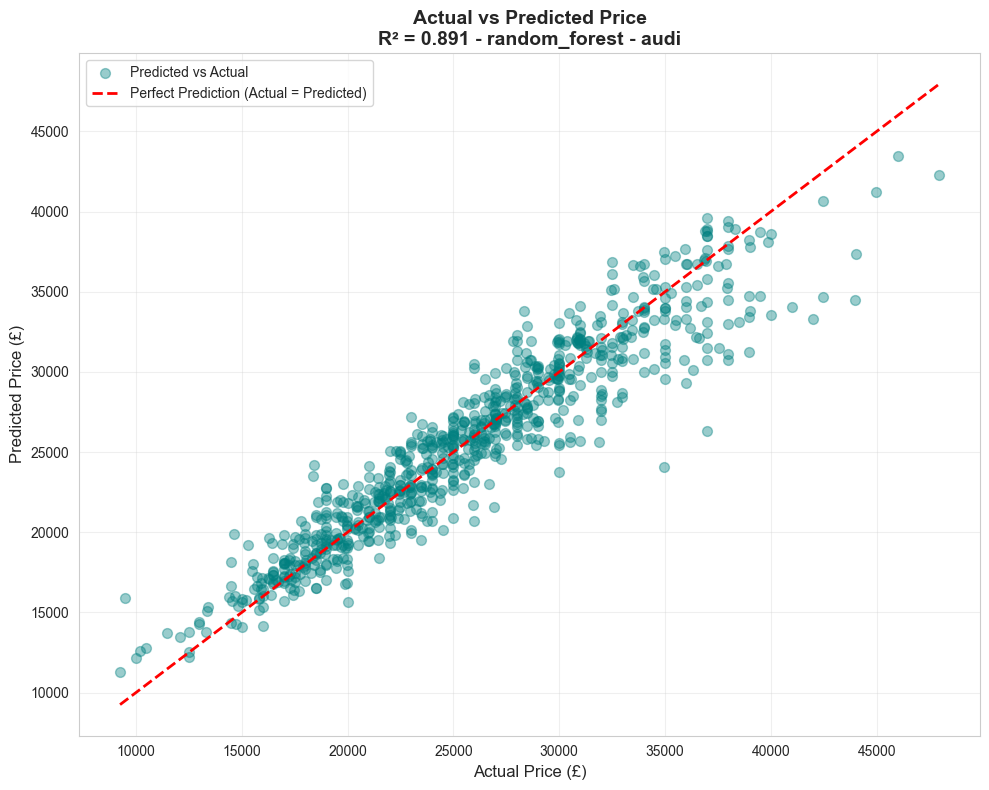

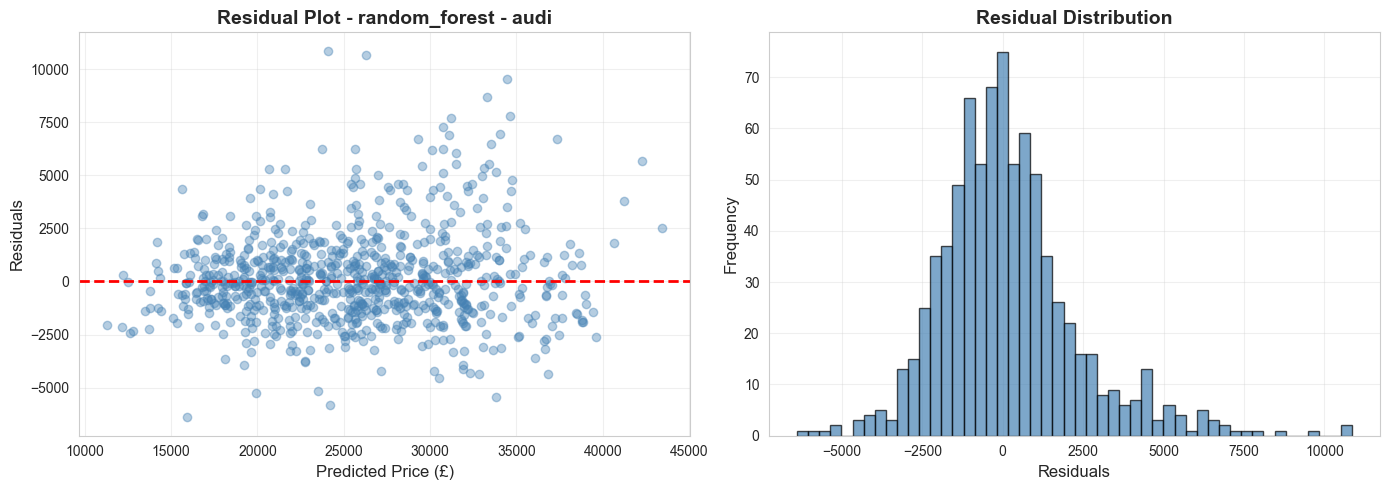

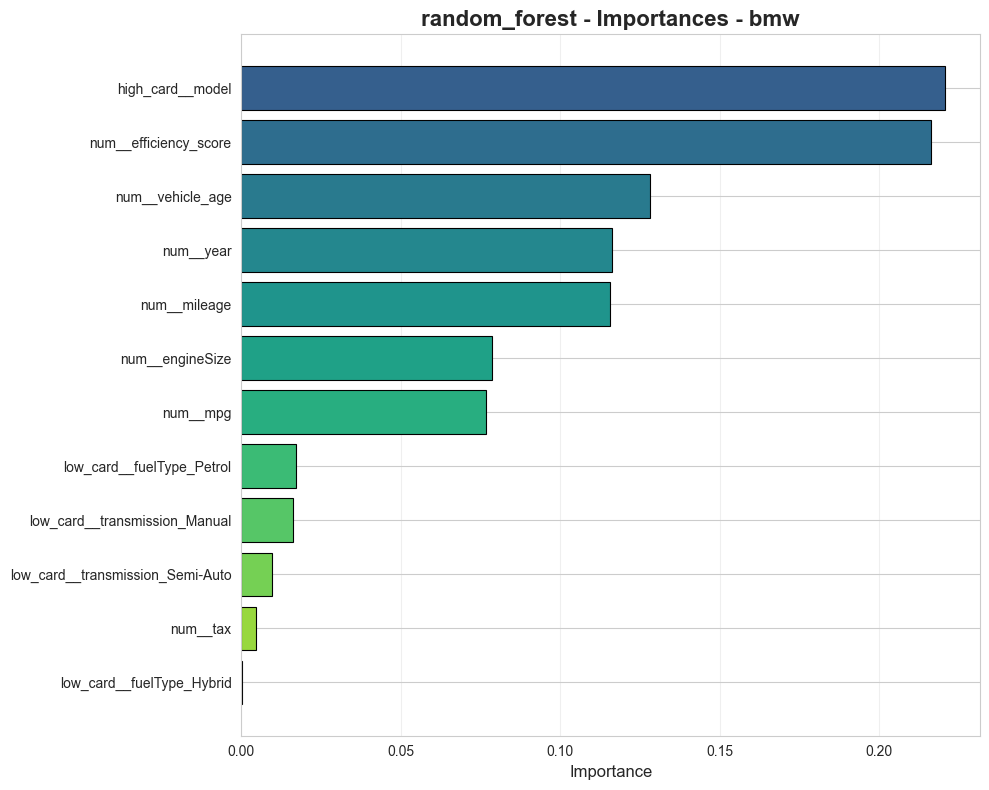

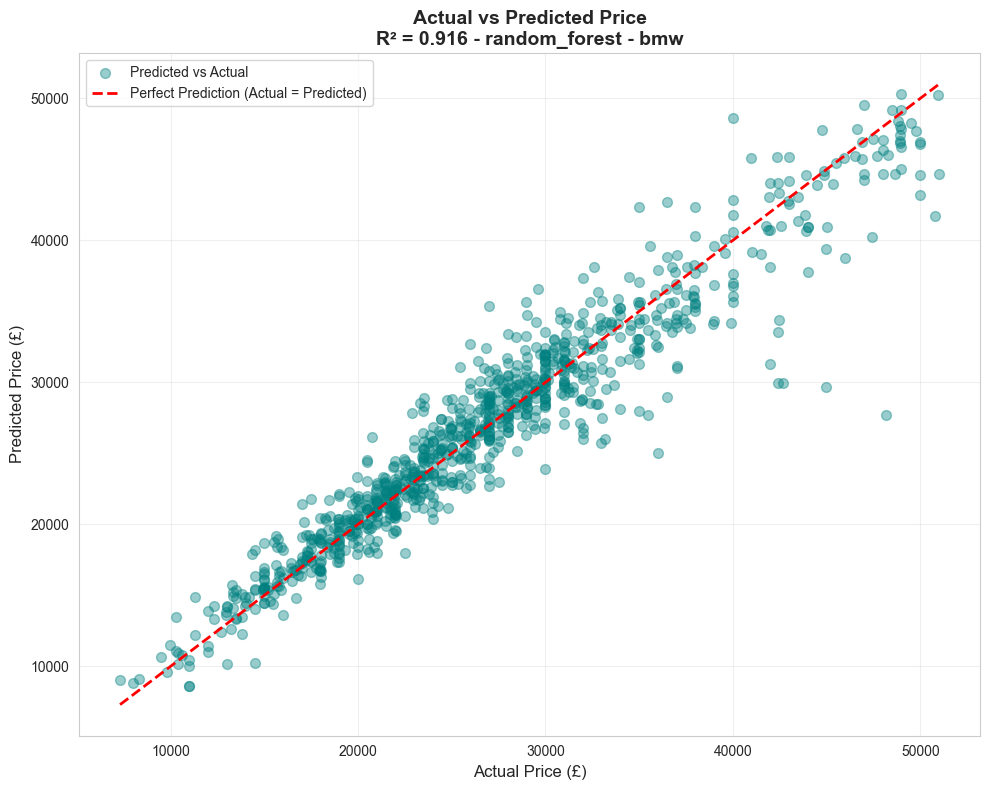

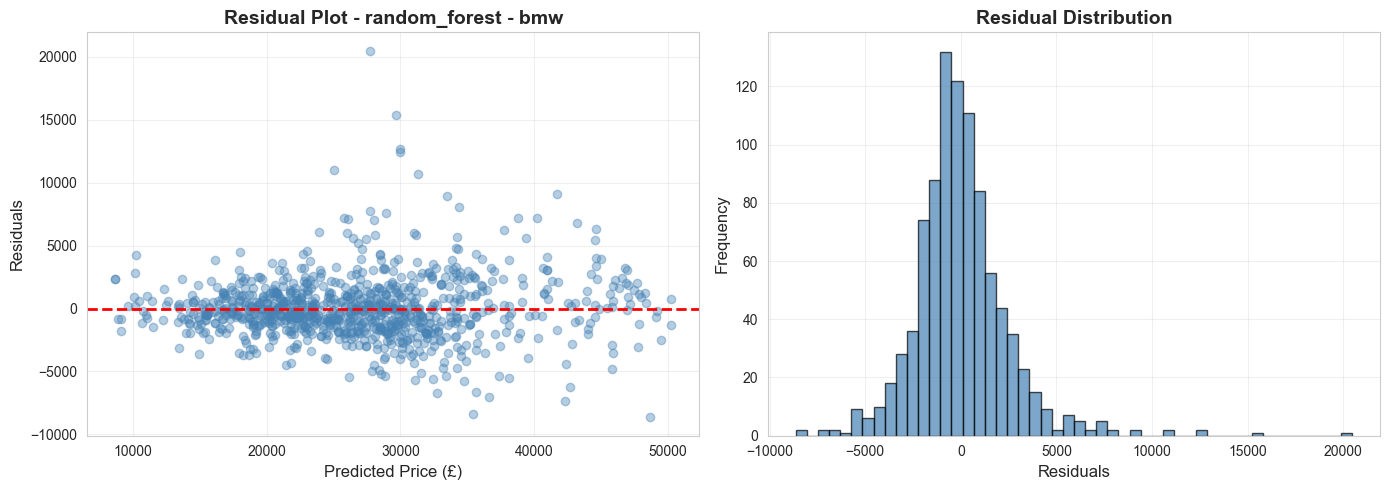

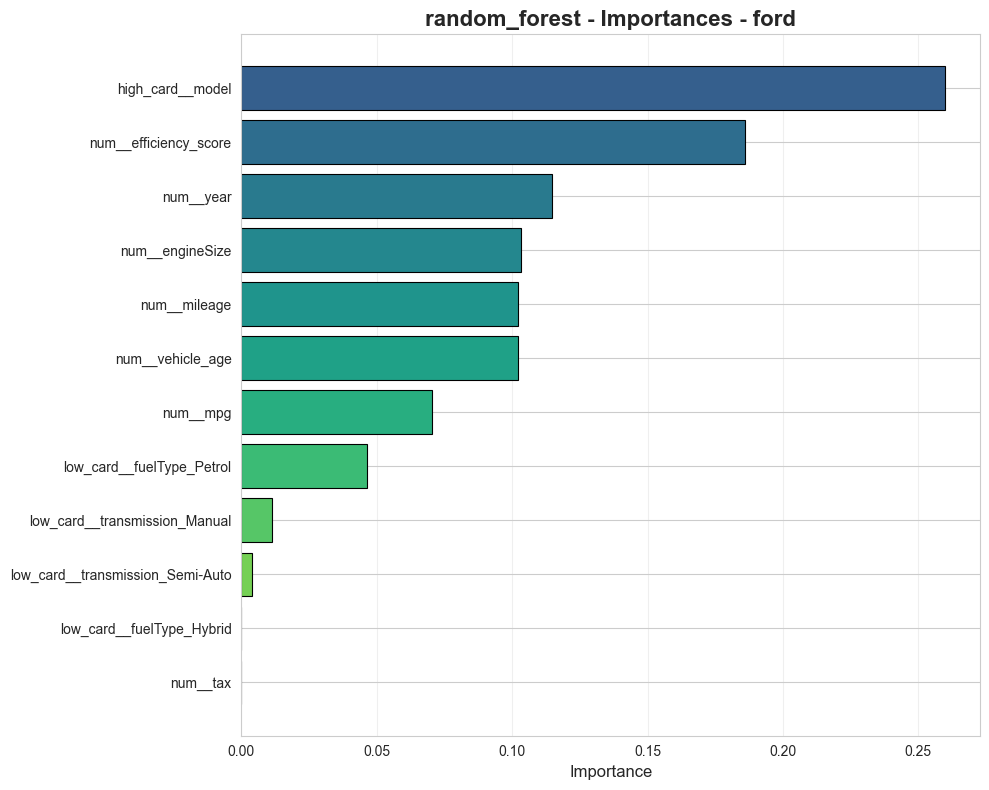

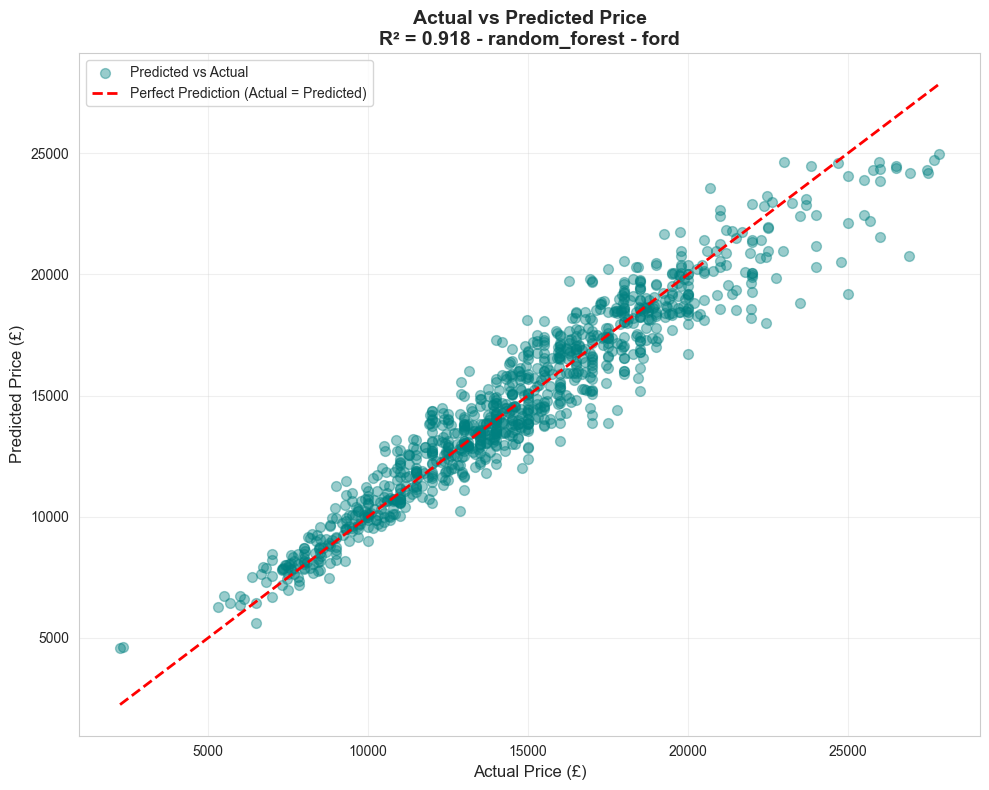

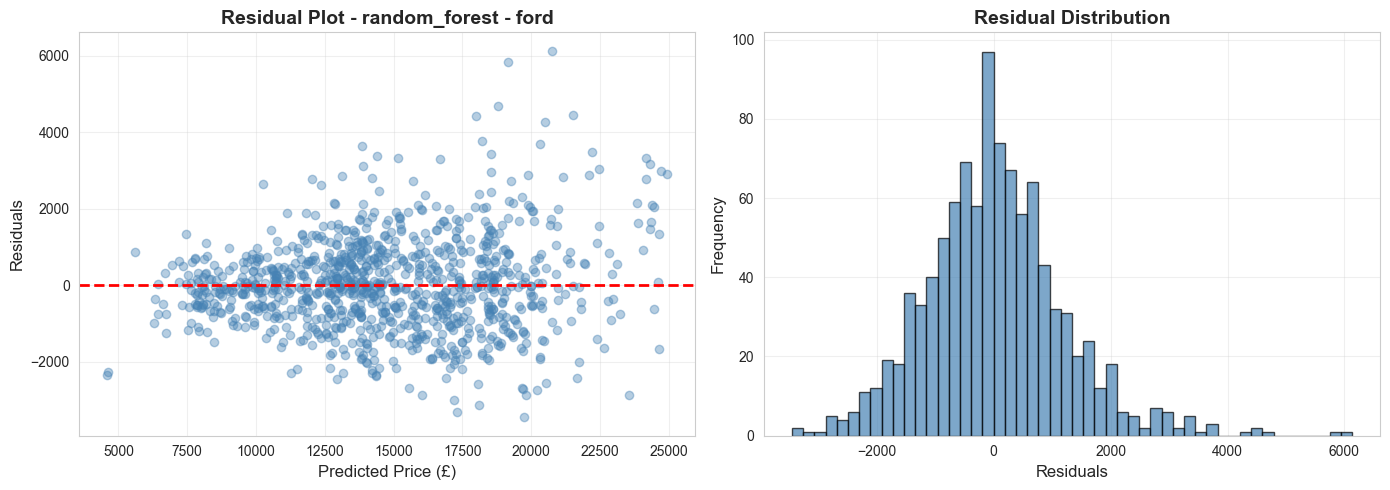

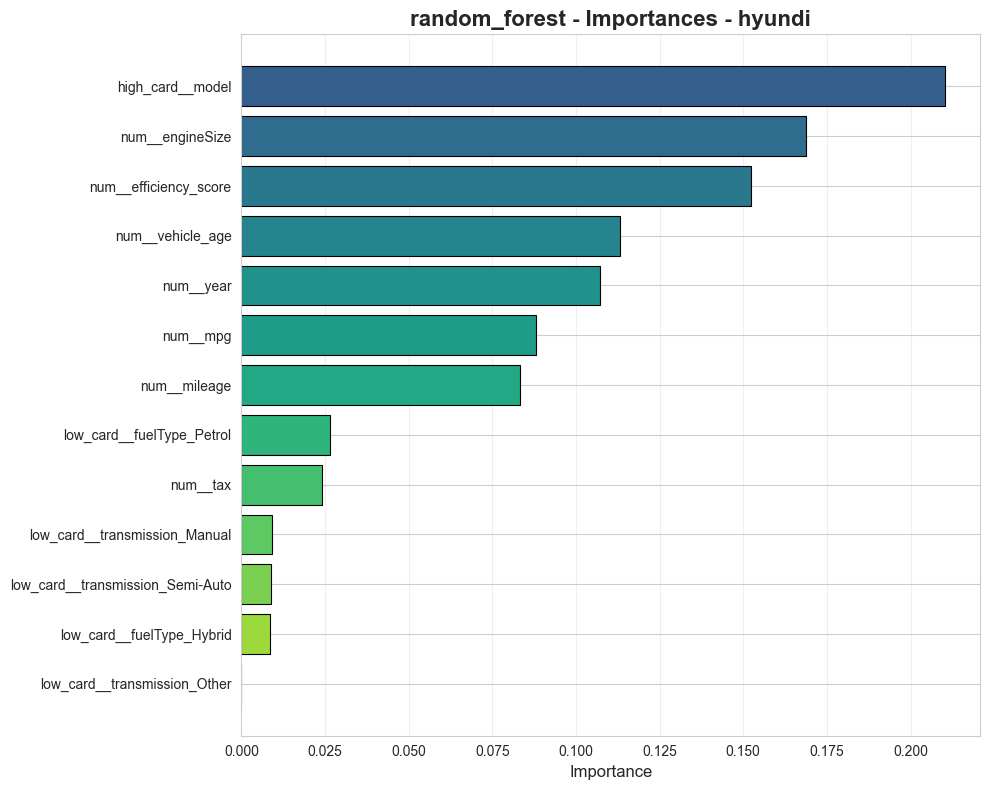

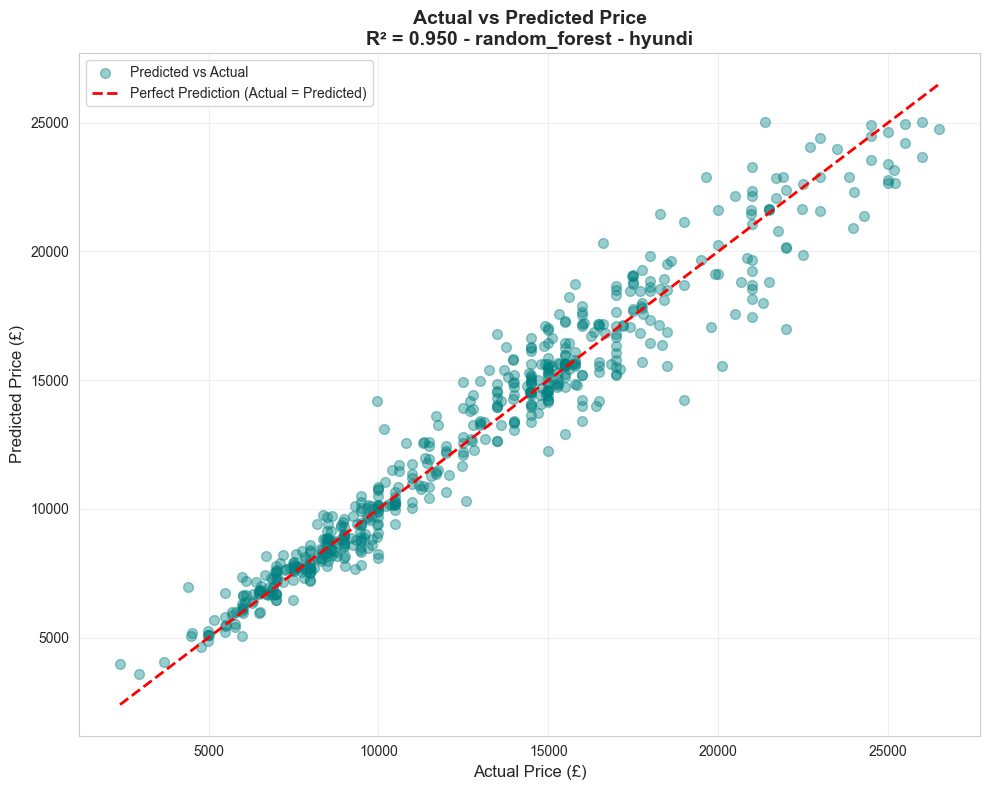

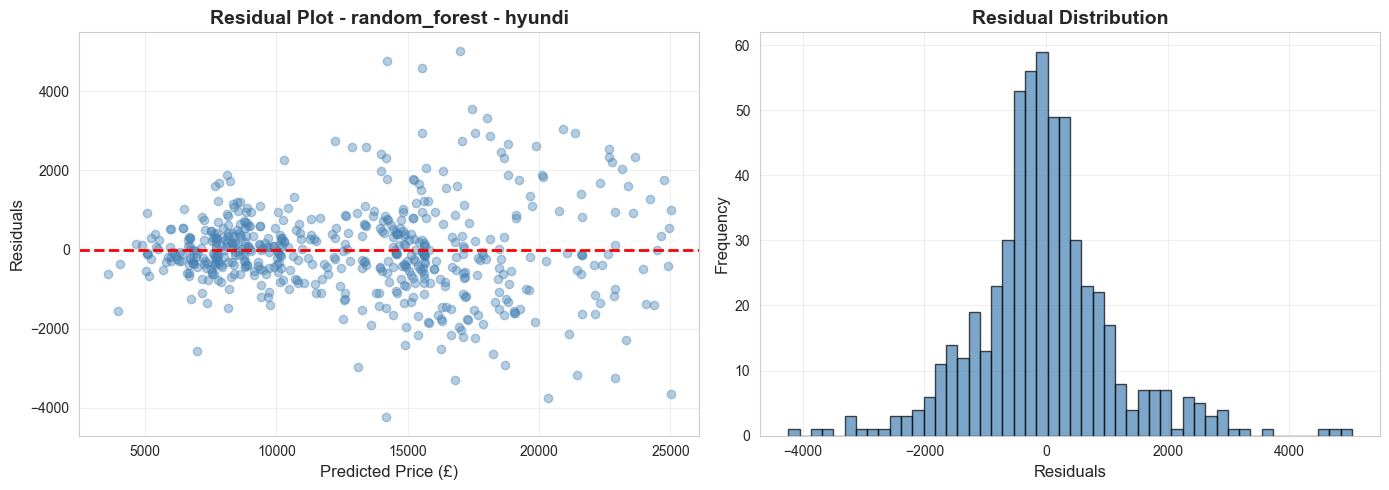

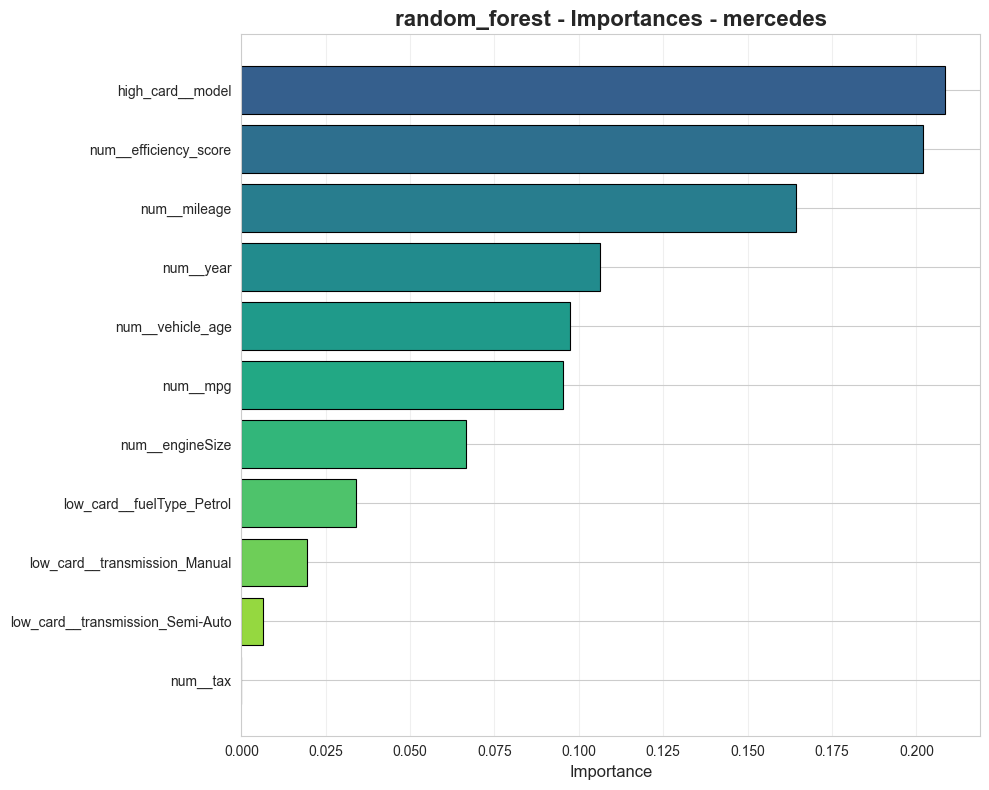

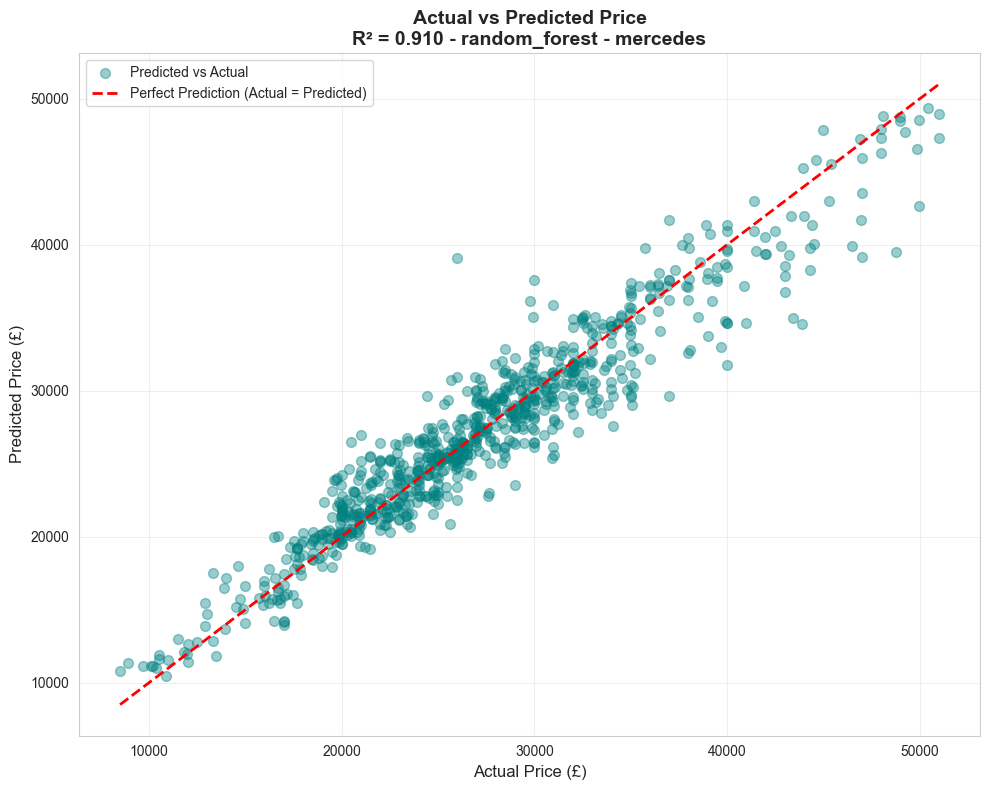

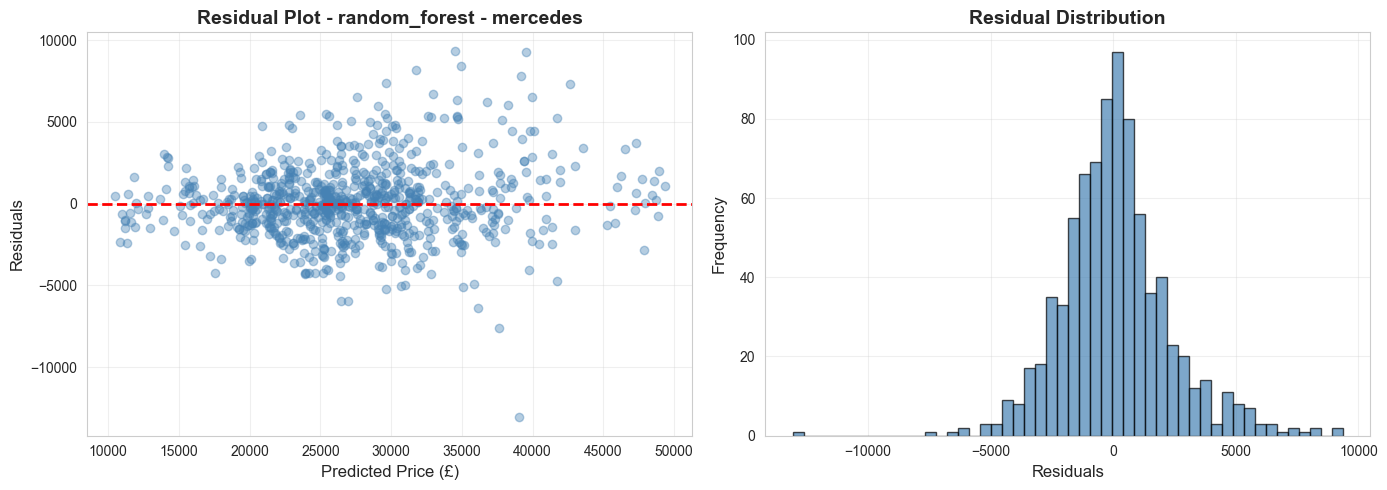

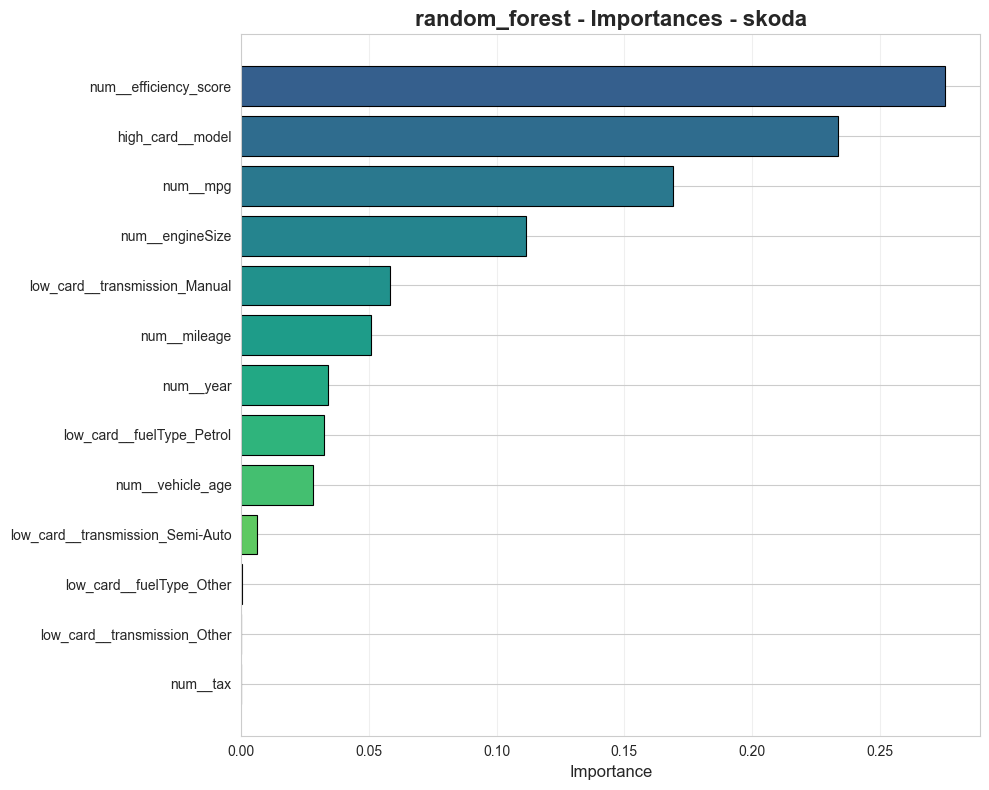

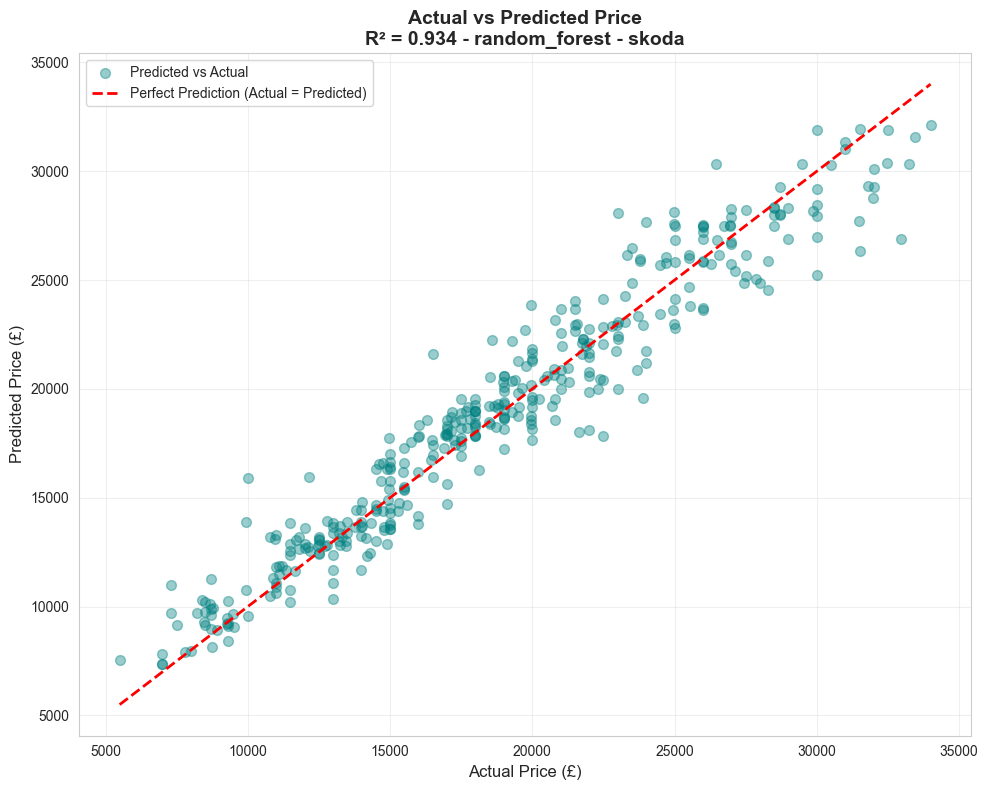

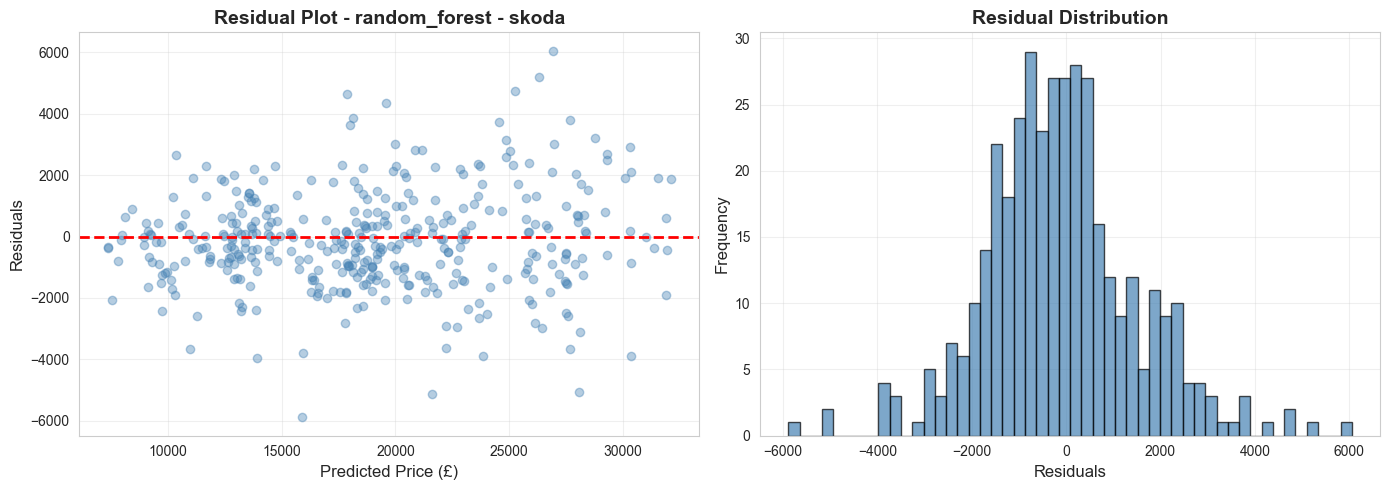

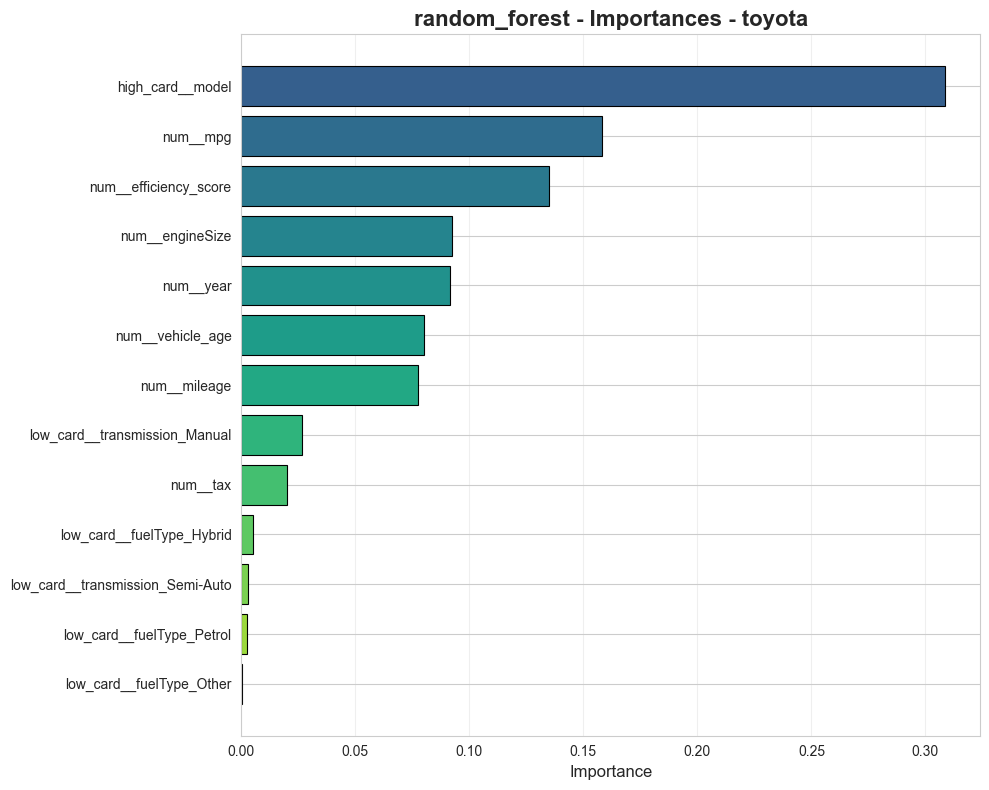

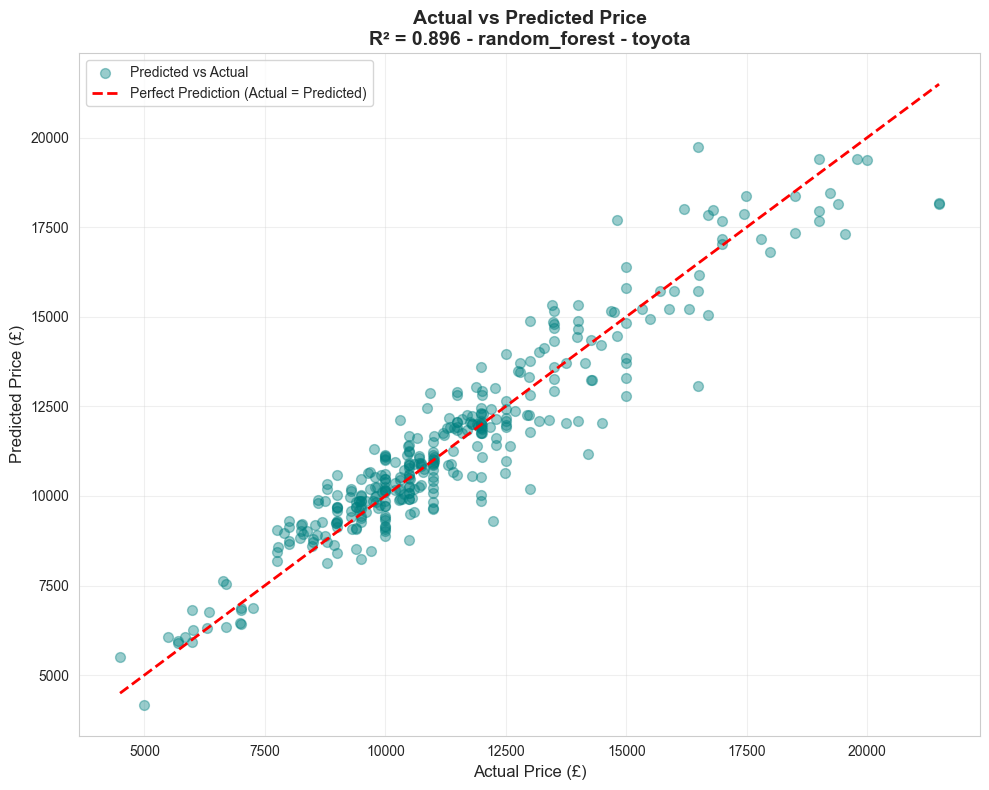

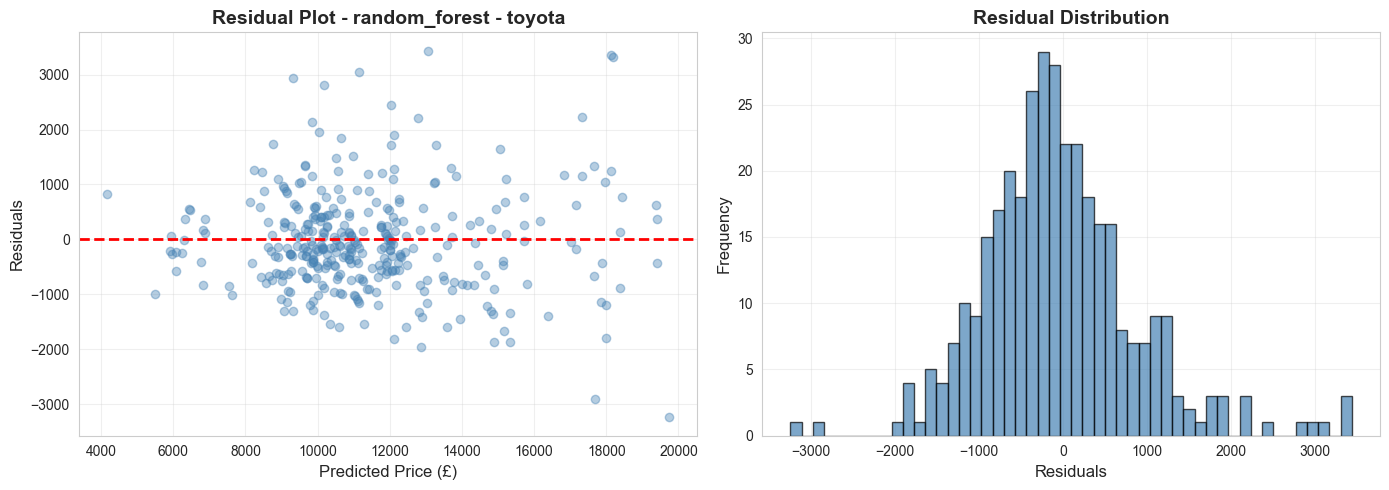

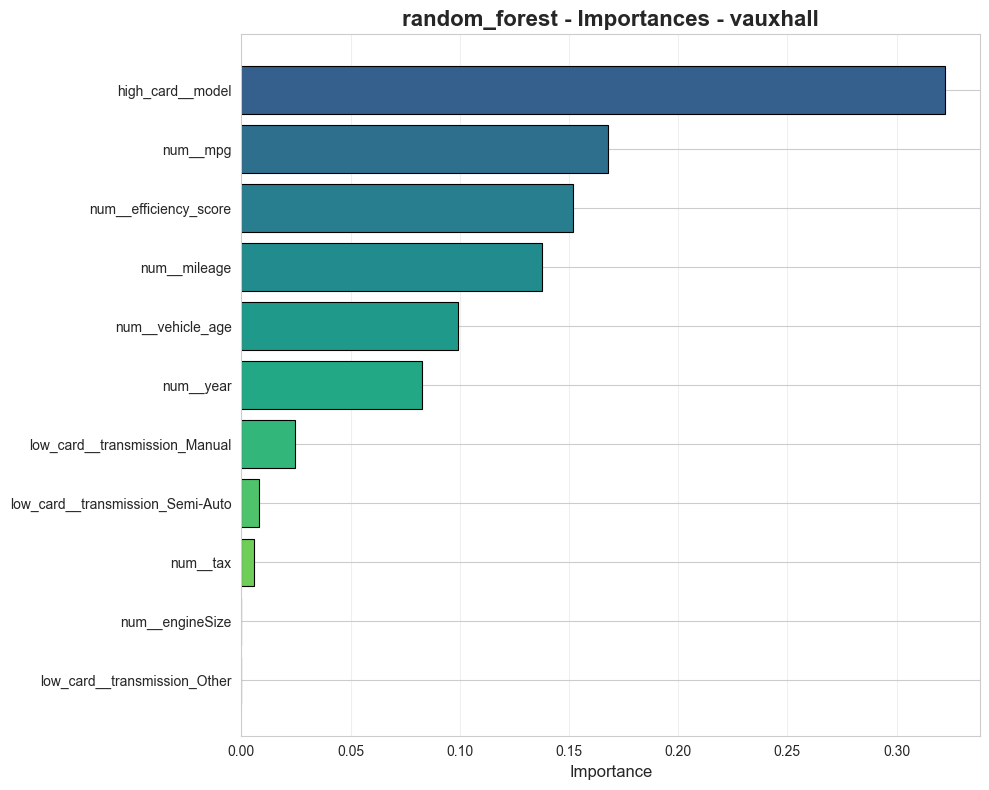

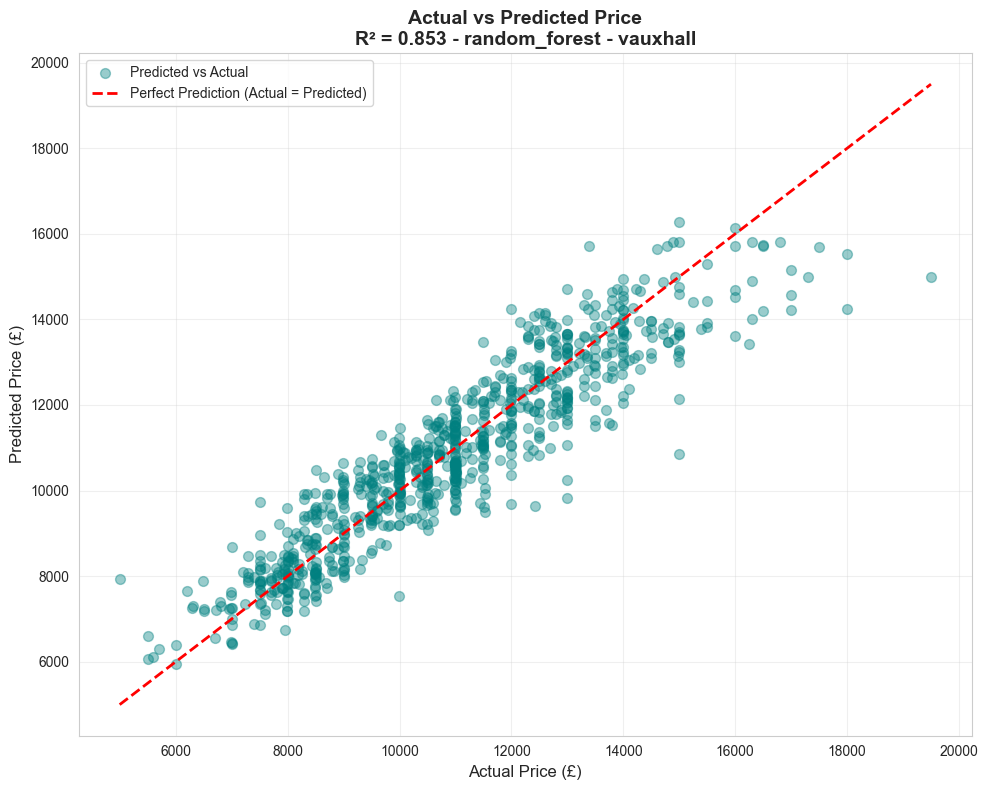

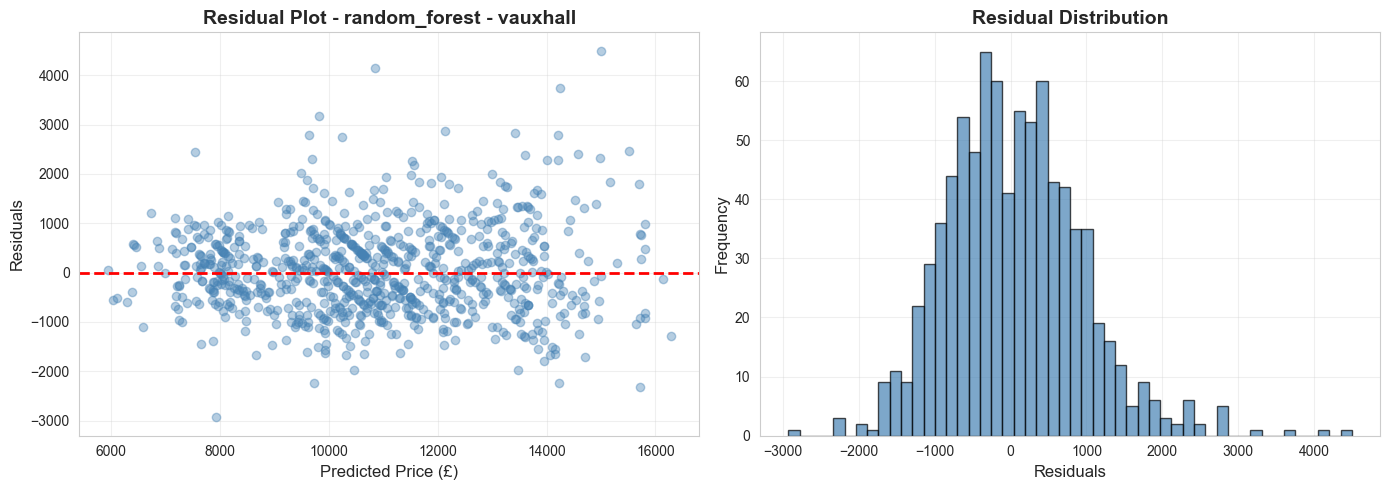

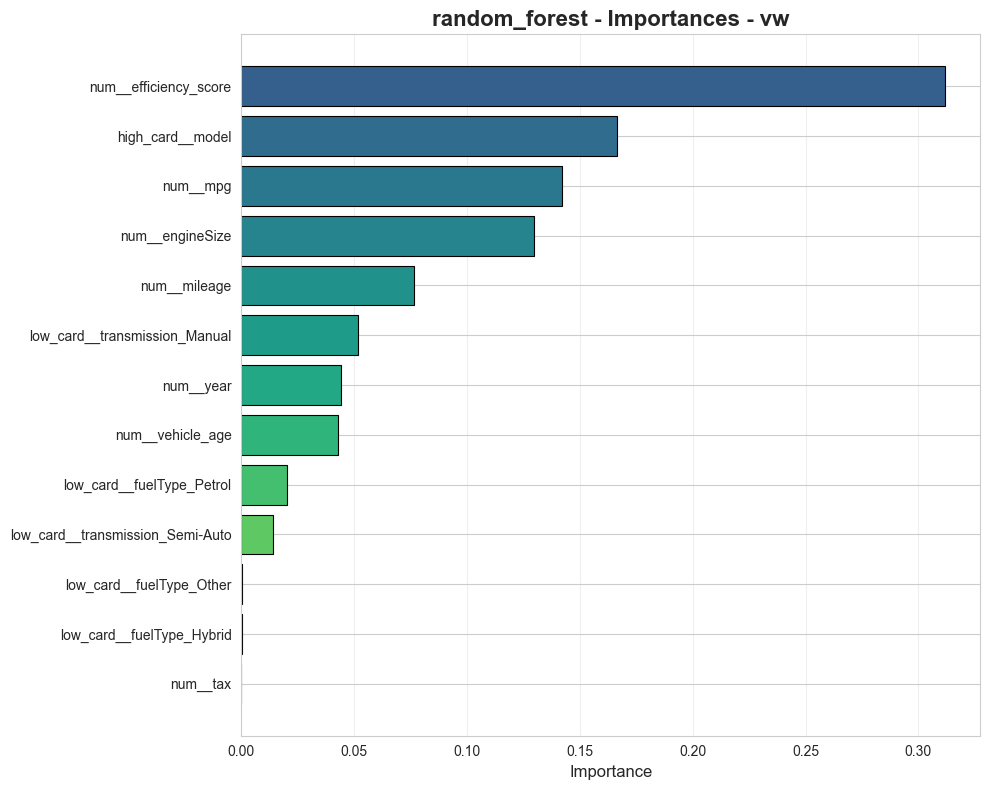

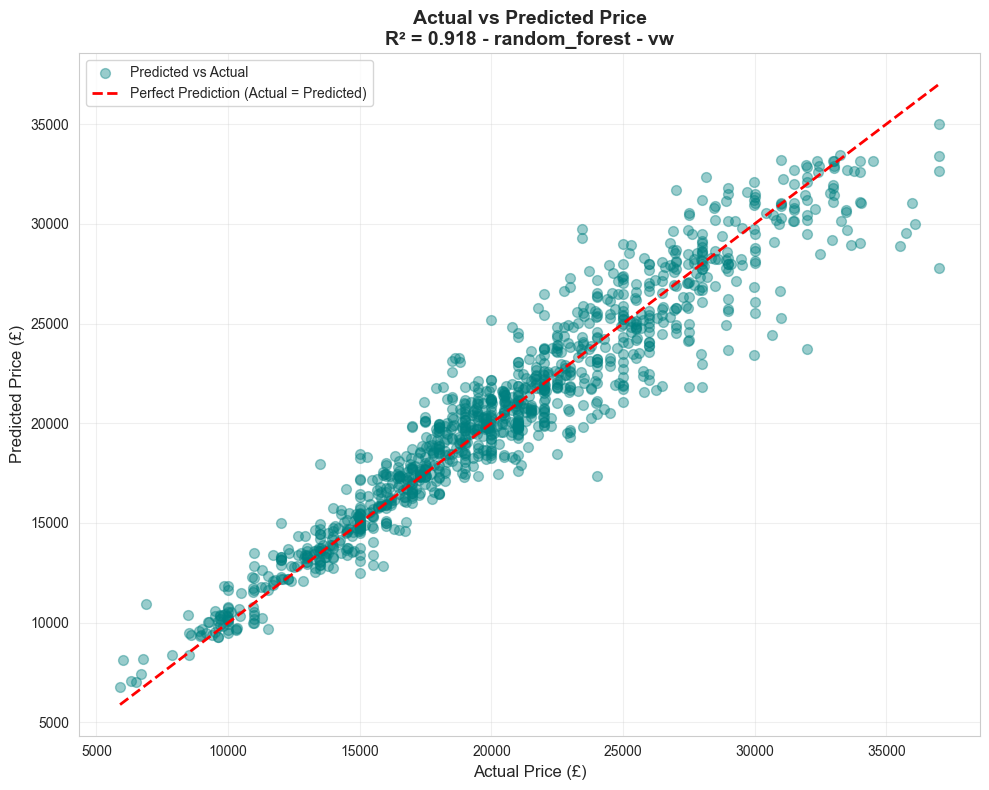

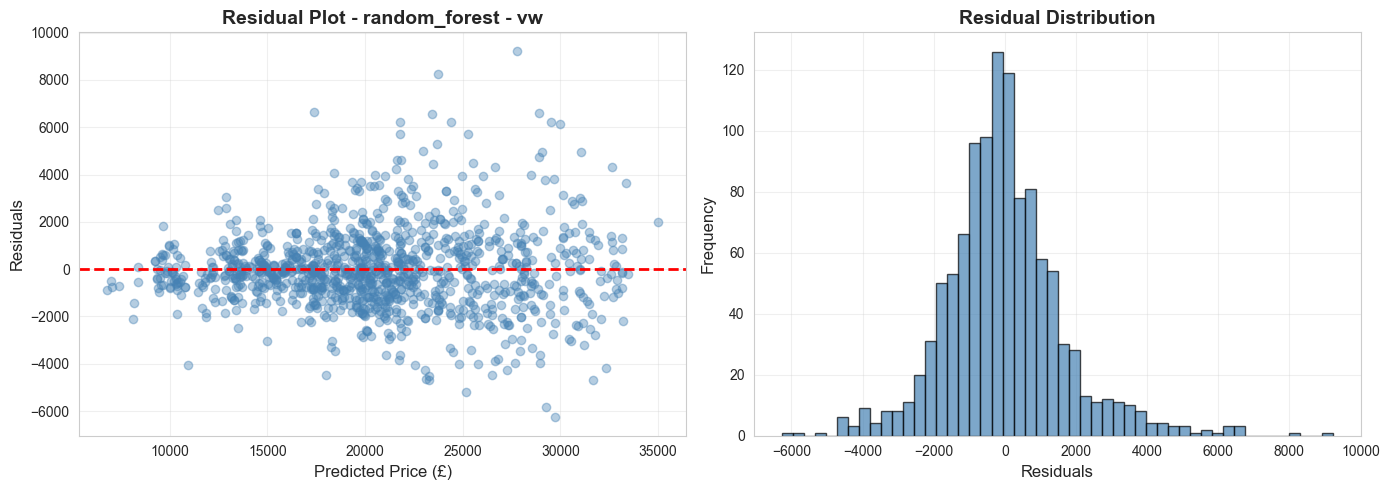

In [20]:
for make_vehicle, data in trained_models_per_make.items():
	model_name = data["best_model_name"]
	model = data["model"]
	y_test = data['y_test']
	feature_names = data["feature_names"]
	predictions = data['predictions']
	metrics = regression_metrics(y_test, predictions)

	values, kind = get_feature_effects(model)

	if values is None:
		print(f"Skipping {make_vehicle} - unsupported model type")
		continue

	n = len(values)
	pipeline = model.best_estimator_ if hasattr(model, "best_estimator_") else model
	feature_names = list(pipeline.named_steps["preprocessing"].get_feature_names_out())
	values = values[:n]
 
	plot_feature_importances(
		values,
		feature_names,
		f"{model_name} - {kind.title()}s - {make_vehicle}"
	)

	# Actual vs Predicted
	plot_actual_vs_predicted(
		y_test, 
		predictions, 
		f'{model_name} - {make_vehicle}', 
		metrics['R2']
	)

	# Residuals plot
	plot_residuals(
		y_test, 
		predictions, 
		f'{model_name} - {make_vehicle}'
	)